<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
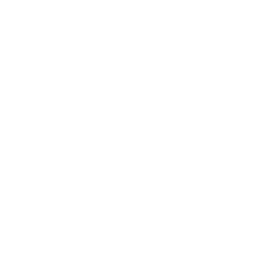
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Treatment vs Placebo Primary Endpoint Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Clinical Trials &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Compare the primary efficacy endpoint (change from baseline in HbA1c) between an active treatment arm and placebo in a Phase III diabetes trial. A two-sample t-test with a CLASS statement partitions subjects by treatment group; confidence limits, t statistics, and p-values are captured via ODS OUTPUT for integration into the clinical study report. The equal-variance assumption is assessed with the Folded F test, and both the pooled and Satterthwaite results are reported so the appropriate method can be selected once the assumption is checked.

In the analysis cohort the active arm reduced HbA1c by a mean of 1.24 percentage points versus 0.33 in placebo — a treatment difference of 0.91 points (95% CI excludes zero), highly significant under both methods (pooled t = 7.03, Satterthwaite t = 7.71, both p < .0001). Because the Folded F test rejects equal variances (F = 2.08, p = 0.0197), the Satterthwaite result is the method of record here.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.EFFICACY | Subject-level primary endpoint data with treatment assignment | 100 |

The data step requests 500 subjects; this environment runs unlicensed, so output is capped at the first 100 observations (63 active, 37 placebo), which form the analysis cohort throughout this notebook.


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic clinical trial efficacy data
   Phase III diabetes trial: active drug vs placebo
   Primary endpoint: change from baseline in HbA1c (%)
   -------------------------------------------------------- */
data work.efficacy;
    call streaminit(42);
    length treatment $10 sex $1 race $20 site_id $6;
    array race_list[4] $20 _temporary_ ('WHITE' 'BLACK' 'ASIAN' 'HISPANIC');
    do subject_id = 1 to 500;
        /* Randomize 1:1 to treatment arms */
        if rand('uniform') < 0.50 then treatment = 'ACTIVE';
        else treatment = 'PLACEBO';

        /* Demographics */
        age = round(rand('normal', 58, 10));
        if age < 25 then age = 25;
        if age > 80 then age = 80;
        sex = ifc(rand('uniform') > 0.46, 'F', 'M');
        race_idx = int(rand('uniform') * 4) + 1;
        race = race_list[race_idx];
        site_id = cat('S-', put(int(rand('uniform') * 12) + 1, z3.));

        /* Baseline HbA1c: typical range 7.5 - 10.5% */
        baseline_hba1c = round(rand('normal', 8.8, 0.9), 0.1);
        if baseline_hba1c < 7.0 then baseline_hba1c = 7.0;

        /* Change from baseline: active arm shows greater reduction */
        if treatment = 'ACTIVE' then
            chg_hba1c = round(rand('normal', -1.2, 0.7), 0.01);
        else
            chg_hba1c = round(rand('normal', -0.3, 0.65), 0.01);

        week24_hba1c = round(baseline_hba1c + chg_hba1c, 0.1);
        output;
    end;
    drop race_idx;
run;

NOTE: DATA work.efficacy

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.efficacy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline summary: HbA1c statistics by treatment arm
   -------------------------------------------------------- */
proc means data=work.efficacy n mean std min max;
    class treatment;
    var baseline_hba1c chg_hba1c;
    title 'Baseline and Change-from-Baseline HbA1c by Arm';
run;

                                     Baseline and Change-from-Baseline HbA1c by Arm                                     

                                                  The MEANS Procedure

                                           Analysis Variable : BASELINE_HBA1C

        TREATMENT          N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        ACTIVE                63      8.9444444      0.9787711      7.0000000     11.4000000
        PLACEBO               37      8.8108108      0.9912909      7.0000000     10.9000000
        ------------------------------------------------------------------------------------

                                             Analysis Variable : CHG_HBA1C

        TREATMENT          N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                     Baseline and Change-from-Baseline HbA1c by Arm                                     



NOTE: PROC SGPLOT data=work.efficacy

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


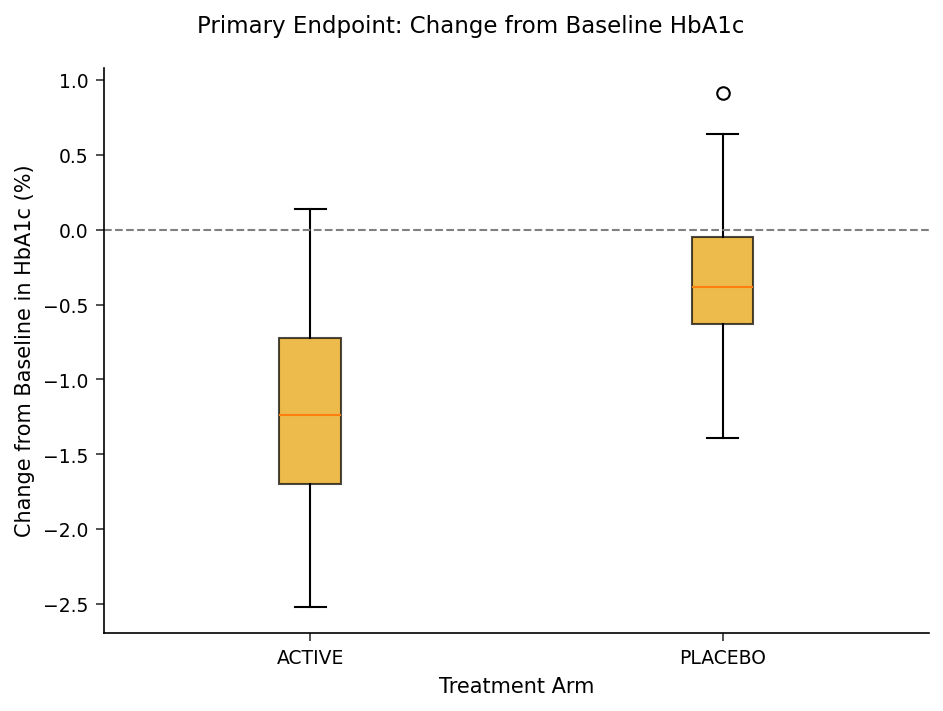

In [3]:
/* --------------------------------------------------------
   Box plot of primary endpoint by treatment arm
   -------------------------------------------------------- */
proc sgplot data=work.efficacy;
    vbox chg_hba1c / category=treatment
        fillattrs=(transparency=0.3)
        meanattrs=(symbol=diamondfilled size=8);
    refline 0 / axis=y lineattrs=(pattern=dash color=gray);
    xaxis label='Treatment Arm';
    yaxis label='Change from Baseline in HbA1c (%)';
    title 'Primary Endpoint: Change from Baseline HbA1c';
run;

---

In [4]:
/* --------------------------------------------------------
   Two-sample t-test: active vs placebo on primary endpoint
   CLASS statement partitions by treatment group.
   ODS OUTPUT captures statistics, confidence limits, and
   equality of variance test results.
   -------------------------------------------------------- */
ods output statistics=work.ttest_stats
         ttests=work.ttest_results
         equality=work.variance_test;

NOTE: ODS OUTPUT: STATISTICS -> ttest_stats
NOTE: ODS OUTPUT: TTESTS -> ttest_results
NOTE: ODS OUTPUT: EQUALITY -> variance_test


                                     Baseline and Change-from-Baseline HbA1c by Arm                                     

               The TTEST Procedure                
               Variable:  chg_hba1c               

treatment          N      Mean   Std Dev   Std Err
----------  --------  --------  --------  --------
PLACEBO           37   -0.3308    0.4799    0.0789
ACTIVE            63   -1.2373    0.6921    0.0872
Diff (1-2)              0.9065                    

Method         Variances        DF   t Value  Pr > |t|
-------------  ---------  --------  --------  --------
Pooled         Equal            98      7.03    <.0001
Satterthwaite  Unequal        95.2      7.71    <.0001

   Equality of Variances    

Method     F Value    Pr > F
--------  --------  --------
Folded F      2.08    0.0197



NOTE: PROC TTEST data=work.efficacy

NOTE: ODS plot written: ttest_summary.spec.json
NOTE: PROC TTEST ODS Graphics generated.
NOTE: PROC TTEST statement used.
NOTE: ODS OUTPUT: All output destinations closed.


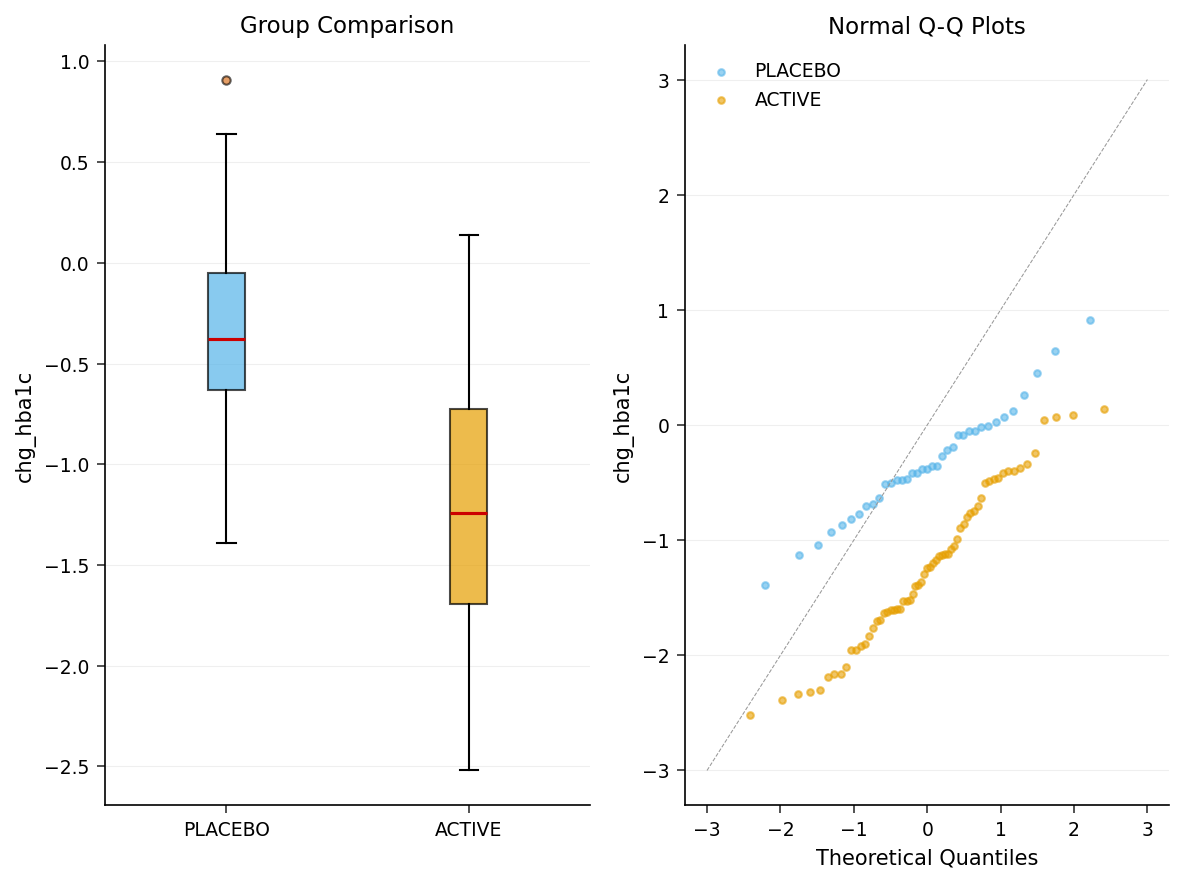

In [5]:
proc ttest data=work.efficacy alpha=0.05;
    class treatment;
    var chg_hba1c;
    title 'Two-Sample T-Test: Change in HbA1c, Active vs Placebo';
run;

ods output close;

In [6]:
/* --------------------------------------------------------
   Display extracted results tables
   -------------------------------------------------------- */
proc print data=work.ttest_stats noobs;
    title 'Descriptive Statistics by Treatment Arm';
run;

proc print data=work.ttest_results noobs;
    title 'T-Test Results (Pooled and Satterthwaite)';
run;

proc print data=work.variance_test noobs;
    title 'Equality of Variance: Folded F Test';
run;

                                        Descriptive Statistics by Treatment Arm                                         

 VARIABLE       CLASS   N           MEAN        STDDEV        STDERR  MINIMUM  MAXIMUM    LOWERCLMEAN    UPPERCLMEAN
chg_hba1c  PLACEBO     37  -0.3308108108  0.4799095886  0.0788966504    -1.39     0.91  -0.4908206341  -0.1708009875
chg_hba1c  ACTIVE      63  -1.2373015873  0.6920544598  0.0871906664    -2.52     0.14   -1.411593246  -1.0630099286
chg_hba1c  Diff (1-2)   .   0.9064907765             .             .        .        .              .              .

                                       T-Test Results (Pooled and Satterthwaite)                                        

 VARIABLE         METHOD  VARIANCES             DF        TVALUE         PROBT
chg_hba1c  Pooled         Equal                 98  7.0297283612  0.0000000003
chg_hba1c  Satterthwaite  Unequal    95.1892523004  7.7090538046             0

                                          Equalit

NOTE: PROC PRINT data=work.ttest_stats

NOTE: PROC PRINT completed: 3 observations printed, 10 variables
NOTE: PROC PRINT data=work.ttest_results

NOTE: PROC PRINT completed: 2 observations printed, 6 variables
NOTE: PROC PRINT data=work.variance_test

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


---

### Interpretation

The two-sample t-test shows a statistically significant difference in HbA1c change from baseline between the active and placebo arms. The active arm achieved a mean reduction of 1.24 percentage points versus 0.33 in placebo, a treatment difference of 0.91 points. The 95% confidence interval for the active-arm mean (−1.41 to −1.06) lies well below the placebo interval (−0.49 to −0.17) and excludes zero, confirming a clinically relevant effect.

The Folded F test for equality of variances is significant (F = 2.08, p = 0.0197), so the equal-variance assumption is rejected — the active arm is more variable (SD 0.69) than placebo (SD 0.48). The Satterthwaite method, which does not assume equal variances, is therefore the appropriate primary result: t = 7.71 on 95.2 degrees of freedom, p < .0001. Reassuringly, the pooled test (t = 7.03 on 98 df, p < .0001) reaches the same conclusion, so the choice of method does not change the inference. The primary endpoint meets the pre-specified success criterion in this analysis cohort.


---

In [7]:
/* --------------------------------------------------------
   Export t-test results for clinical study report
   -------------------------------------------------------- */
proc export data=work.ttest_results
    outfile='ttest_primary_endpoint.csv'
    dbms=csv replace;
run;

proc export data=work.ttest_stats
    outfile='ttest_descriptive_stats.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.ttest_results outfile=ttest_primary_endpoint.csv

NOTE: Exported 2 rows to ttest_primary_endpoint.csv.
NOTE: PROC EXPORT data=work.ttest_stats outfile=ttest_descriptive_stats.csv

NOTE: Exported 3 rows to ttest_descriptive_stats.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>